In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [42]:
import cv2
import PIL.Image as Image
import os

import tensorflow as tf 
import tensorflow_hub as hub

from tensorflow import keras 
from tensorflow.keras import layers 
from tensorflow.keras.models import Sequential

In [51]:
import pathlib

data_dir = pathlib.Path("E:/jupiter_notebook/datasets/PlantVillage dataset/color/")
data_dir

WindowsPath('E:/jupiter_notebook/datasets/PlantVillage dataset/color')

In [52]:
def walk_through_dir(dir_path):
    "Walks through each directory in our dataset folder"
    for dirpath , dirnames , filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [53]:
walk_through_dir(data_dir)

There are 38 directories and 0 images in E:\jupiter_notebook\datasets\PlantVillage dataset\color
There are 0 directories and 630 images in E:\jupiter_notebook\datasets\PlantVillage dataset\color\Apple___Apple_scab
There are 0 directories and 621 images in E:\jupiter_notebook\datasets\PlantVillage dataset\color\Apple___Black_rot
There are 0 directories and 275 images in E:\jupiter_notebook\datasets\PlantVillage dataset\color\Apple___Cedar_apple_rust
There are 0 directories and 1645 images in E:\jupiter_notebook\datasets\PlantVillage dataset\color\Apple___healthy
There are 0 directories and 1502 images in E:\jupiter_notebook\datasets\PlantVillage dataset\color\Blueberry___healthy
There are 0 directories and 854 images in E:\jupiter_notebook\datasets\PlantVillage dataset\color\Cherry_(including_sour)___healthy
There are 0 directories and 1052 images in E:\jupiter_notebook\datasets\PlantVillage dataset\color\Cherry_(including_sour)___Powdery_mildew
There are 0 directories and 513 images in

In [54]:
#Opening images using PIL
import random

# getting image paths
image_path_list  = list(data_dir.glob("*/*.jpg")) 
# Data_dir takes us to all image folder
#from theere we want any image therefore */* which tells any folder and any image is fine as long as it is jpg

image_path_list

[WindowsPath('E:/jupiter_notebook/datasets/PlantVillage dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG'),
 WindowsPath('E:/jupiter_notebook/datasets/PlantVillage dataset/color/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG'),
 WindowsPath('E:/jupiter_notebook/datasets/PlantVillage dataset/color/Apple___Apple_scab/01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG'),
 WindowsPath('E:/jupiter_notebook/datasets/PlantVillage dataset/color/Apple___Apple_scab/0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG'),
 WindowsPath('E:/jupiter_notebook/datasets/PlantVillage dataset/color/Apple___Apple_scab/023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487.JPG'),
 WindowsPath('E:/jupiter_notebook/datasets/PlantVillage dataset/color/Apple___Apple_scab/0261a6e4-21f8-481a-8827-b674e6955644___FREC_Scab 3055.JPG'),
 WindowsPath('E:/jupiter_notebook/datasets/PlantVillage dataset/color/Apple___Apple_scab/029424b0-0e

In [55]:
# Now we pick a random image path
random_path = random.choice(image_path_list)
print(random_path)
#We now retrive our image label which is just the folder name it is stored in 
image_class = random_path.parent.stem
print(image_class)

E:\jupiter_notebook\datasets\PlantVillage dataset\color\Tomato___Tomato_mosaic_virus\0fcf9c2a-5c8c-4f37-aa43-6fd41d5e5442___PSU_CG 2055.JPG
Tomato___Tomato_mosaic_virus


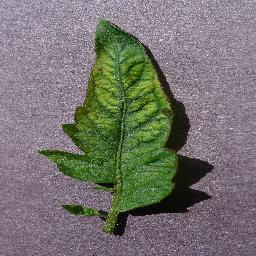

In [56]:
#Open image
img = Image.open(random_path)
img

In [57]:
# Metadata ( add path and image name if like)
print(f"image height : {img.height}")
print(f"image weidth : {img.width}")

image height : 256
image weidth : 256


In [58]:
sum = 0
for dirpath , dirnames , filenames in os.walk(data_dir):
       sum += len(filenames)

print(f"Total samples : {sum}")

Total samples : 54305


In [123]:
min_len = 10000 
max_len = 0 
length_list = []

for class_name in os.listdir(data_dir): 
    class_path = os.path.join(data_dir, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name} contains {num_images} images")
       
        if num_images < min_len:
            min_len = num_images
        if num_images > max_len:
            max_len = num_images

        length_list.append(num_images)
    
print(f"max length : {max_len} , min length : {min_len}") 
length_list = np.sort(length_list) 
print(length_list)

Apple___Apple_scab contains 630 images
Apple___Black_rot contains 621 images
Apple___Cedar_apple_rust contains 275 images
Apple___healthy contains 1645 images
Blueberry___healthy contains 1502 images
Cherry_(including_sour)___healthy contains 854 images
Cherry_(including_sour)___Powdery_mildew contains 1052 images
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot contains 513 images
Corn_(maize)___Common_rust_ contains 1192 images
Corn_(maize)___healthy contains 1162 images
Corn_(maize)___Northern_Leaf_Blight contains 985 images
Grape___Black_rot contains 1180 images
Grape___Esca_(Black_Measles) contains 1383 images
Grape___healthy contains 423 images
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) contains 1076 images
Orange___Haunglongbing_(Citrus_greening) contains 5507 images
Peach___Bacterial_spot contains 2297 images
Peach___healthy contains 360 images
Pepper,_bell___Bacterial_spot contains 997 images
Pepper,_bell___healthy contains 1478 images
Potato___Early_blight contains 1000 ima

In [63]:
import torch

In [147]:
class_counts = np.array(length_list) 
class_weights = 1.0 / 38
class_weights = weights / (np.sum(class_weights)) * class_counts

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [148]:
class_weights

tensor([ 219488.,  397100.,  519840.,  535724.,  538612.,  610812.,  658464.,
         740772.,  896724.,  909720., 1233176., 1374688., 1422340., 1439668.,
        1444000., 1444000., 1444000., 1519088., 1553744., 1601396., 1677928.,
        1703920., 1721248., 1997052., 2027376., 2134232., 2168888., 2297404.,
        2375380., 2420144., 2557324., 2649740., 2756596., 3071388., 3316868.,
        7349960., 7735508., 7952108.], device='cuda:0')

In [149]:
class_weights = class_weights.to(device)

In [140]:
len(length_list)

38

In [133]:
np.array(length_list) 

array([ 152,  275,  360,  371,  373,  423,  456,  513,  621,  630,  854,
        952,  985,  997, 1000, 1000, 1000, 1052, 1076, 1109, 1162, 1180,
       1192, 1383, 1404, 1478, 1502, 1591, 1645, 1676, 1771, 1835, 1909,
       2127, 2297, 5090, 5357, 5507])

In [135]:
np.sum(weights)

np.float64(38.0)

In [150]:
class_weights.shape

torch.Size([38])

PIPELINES

In [69]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [72]:
val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [73]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(root=data_dir, transform=train_transforms)

In [74]:
print(len(dataset))
print(len(dataset.classes))

54305
38


In [187]:
from torch.utils.data import random_split

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

In [188]:
train_size

38013

In [189]:
val_dataset.dataset.transform = val_transforms
test_dataset.dataset.transform = val_transforms

In [190]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset, batch_size = 64 , shuffle = True , num_workers=4, pin_memory=True
)

val_loader = DataLoader(
    val_dataset , batch_size = 64, shuffle = False , num_workers=4, pin_memory=True
)

test_loader = DataLoader(
    test_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)

In [164]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 224, 224])
torch.Size([64])


In [82]:
print(torch.cuda.is_available())

True


In [165]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [166]:
import torch.nn as nn

class PlantDiseaseCNN(nn.Module):

    def __init__(self, num_classes = 38):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding = 1), # 3 = RGB(input channels) , 32 = Filters(output channels)
            nn.ReLU(),
            nn.MaxPool2d(2), #Divides images into half (2,2 maxpool)

            nn.Conv2d(32, 64, kernel_size=3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),
            nn.Linear(128*28*28 , 512), # input and output layers dimensions 
            
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512 , num_classes) # num_classes = 38 , final predicted classes
        )

    def forward(self,x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [167]:
model = PlantDiseaseCNN().to(device)

In [168]:
#Loss Function
criterion = nn.CrossEntropyLoss(weight=class_weights).to(device)

In [169]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [170]:
dummy = torch.randn(1,3,224,224).to(device)
output = model(dummy)

print(output.shape)

torch.Size([1, 38])


In [171]:
def calculate_accuracy(outputs , labels):
    _, predicted = torch.max(outputs , 1)

    correct = (predicted == labels).sum().item()
    total = labels.size(0)

    return correct/total

In [172]:
def train_one_epoch(model , dataloader , criterion , optimizer , device):

    model.train()

    running_loss = 0
    running_acc =0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs,labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_acc += calculate_accuracy(outputs , labels)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = running_acc / len(dataloader)

    return epoch_loss, epoch_acc

In [173]:
def validate_one_epoch(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0
    running_acc = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()
            running_acc += calculate_accuracy(outputs, labels)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = running_acc / len(dataloader)

    return epoch_loss, epoch_acc

In [174]:
import time

In [175]:
print(next(model.parameters()).device)

cuda:0


In [177]:
start = time.time()

num_epochs = 10
best_val_acc = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print("-"*40)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_plant_disease_model.pth"
        )
        
end = time.time()
print(f"Time taken : {(end - start)/60} minutes")

model.load_state_dict(torch.load("best_plant_disease_model.pth", weights_only=True))
model.eval()

Epoch 1/10
Train Loss: 0.4908 | Train Acc: 0.7734
Val Loss: 0.3309 | Val Acc: 0.8395
----------------------------------------
Epoch 2/10
Train Loss: 0.3050 | Train Acc: 0.8506
Val Loss: 0.2487 | Val Acc: 0.8953
----------------------------------------
Epoch 3/10
Train Loss: 0.2190 | Train Acc: 0.8897
Val Loss: 0.2351 | Val Acc: 0.9138
----------------------------------------
Epoch 4/10
Train Loss: 0.1741 | Train Acc: 0.9115
Val Loss: 0.2641 | Val Acc: 0.9148
----------------------------------------
Epoch 5/10
Train Loss: 0.1426 | Train Acc: 0.9245
Val Loss: 0.2115 | Val Acc: 0.9236
----------------------------------------
Epoch 6/10
Train Loss: 0.1084 | Train Acc: 0.9402
Val Loss: 0.2250 | Val Acc: 0.9312
----------------------------------------
Epoch 7/10
Train Loss: 0.0997 | Train Acc: 0.9450
Val Loss: 0.2199 | Val Acc: 0.9302
----------------------------------------
Epoch 8/10
Train Loss: 0.0956 | Train Acc: 0.9475
Val Loss: 0.2158 | Val Acc: 0.9270
---------------------------------

PlantDiseaseCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=38, bias=True)
  )
)

In [183]:
print(type(test_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [191]:
model.load_state_dict(torch.load("best_plant_disease_model.pth", weights_only=True))
model.eval()
test_loss, test_acc = validate_one_epoch(
    model,
    test_loader,
    criterion,
    device
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

Test Accuracy: 0.976318359375
Test Loss: 0.10237013756886881


In [186]:
print(type(test_dataset))
print(type(test_loader))

<class 'torch.utils.data.dataloader.DataLoader'>
<class 'torch.utils.data.dataloader.DataLoader'>


In [2]:
#These are for temporary use only , use training produced results for graph plotting

train_losses = [0.4908, 0.3050, 0.2190, 0.1741, 0.1426, 0.1084, 0.0997, 0.0956, 0.0883, 0.0622]

val_losses = [0.3309, 0.2487, 0.2351, 0.2641, 0.2115, 0.2250, 0.2199, 0.2158, 0.2699, 0.2526]

train_accuracies = [0.7734, 0.8506, 0.8897, 0.9115, 0.9245, 0.9402, 0.9450, 0.9475, 0.9545, 0.9644]

val_accuracies = [0.8395, 0.8953, 0.9138, 0.9148, 0.9236, 0.9312, 0.9302, 0.9270, 0.9274, 0.9343]

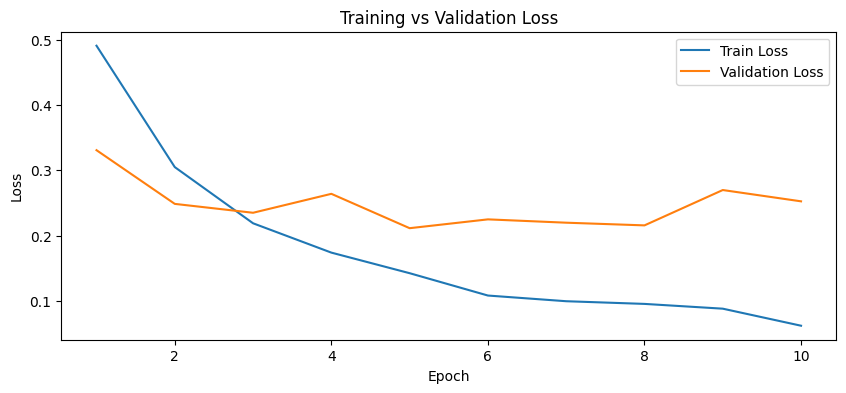

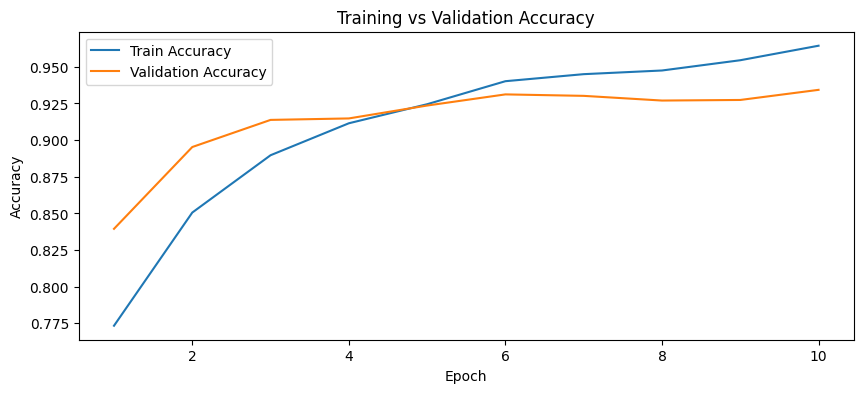

In [3]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# Loss curves
plt.figure(figsize=(10,4))
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig("Training vs Validation Loss")
plt.show()

# Accuracy curves
plt.figure(figsize=(10,4))
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.savefig("Training vs Validation Accuracy")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

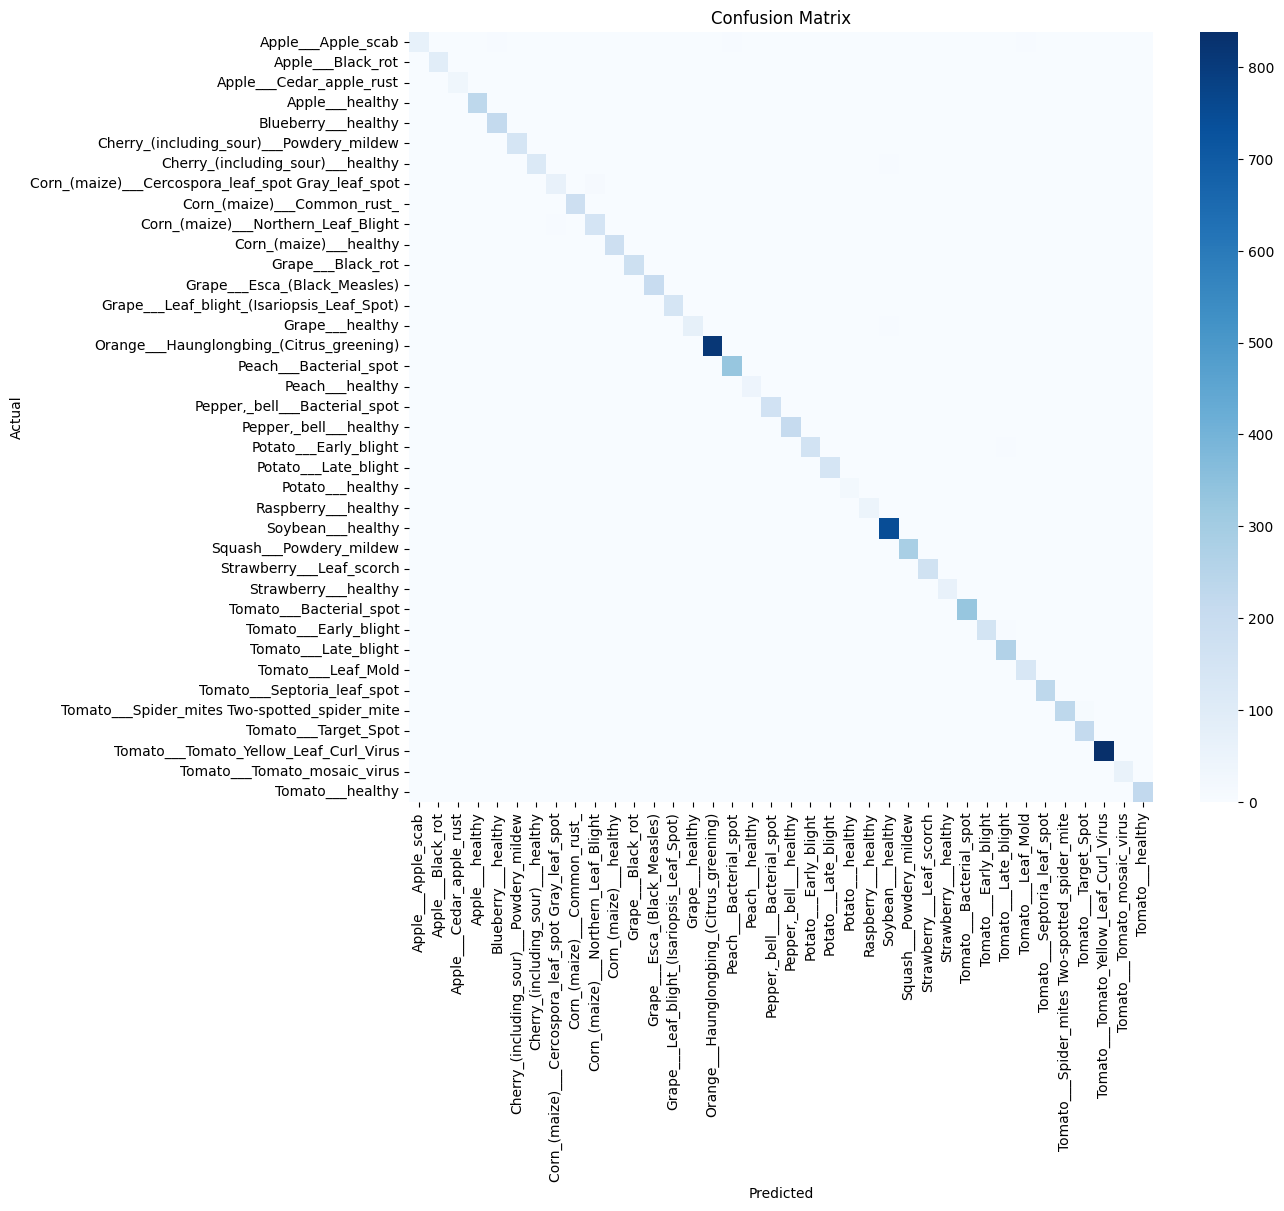

In [196]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()